# First Runthrough

This notebook acts as a first runthrough to inspect the data and train some baseline models to compare against before we productionalize this project.

# Load data

In [2]:
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [78]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# EDA

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [97]:
import pandas as pd
import numpy as np

def eda_summary(df):

    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isnull().sum(),
        "missing_pct": (df.isnull().mean() * 100).round(2),
        "unique_values": df.nunique(),
    })

    summary["feature_type"] = np.select(
        [
            summary["dtype"].isin(["int64", "float64"]),
            summary["unique_values"] <= 10,
        ],
        [
            "numeric",
            "categorical"
        ],
        default="high_cardinality"
    )

    numeric_cols = df.select_dtypes(include=["number"]).columns
    summary["mean"] = df[numeric_cols].mean()
    summary["std"] = df[numeric_cols].std()
    summary["min"] = df[numeric_cols].min()
    summary["max"] = df[numeric_cols].max()
    summary["skew"] = df[numeric_cols].skew()

    summary["top_value"] = df.mode().iloc[0]
    summary["top_freq"] = df.apply(lambda x: x.value_counts().iloc[0] if len(x.value_counts()) > 0 else None)

    return summary.sort_values("missing_pct", ascending=False)

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [98]:
eda_summary(df)

,dtype,missing_count,missing_pct,unique_values,feature_type,mean,std,min,max,skew,top_value,top_freq
customerID,object,0,0.0,7043,high_cardinality,NaN,NaN,NaN,NaN,NaN,0002-ORFBO,1
DeviceProtection,object,0,0.0,3,categorical,NaN,NaN,NaN,NaN,NaN,No,3095
TotalCharges,float64,0,0.0,6534,high_cardinality,2279.798992,2266.730170,18.80,8684.80,0.963316,20.2,11
MonthlyCharges,float64,0,0.0,1585,high_cardinality,64.761692,30.090047,18.25,118.75,-0.220524,20.05,61
PaymentMethod,object,0,0.0,4,categorical,NaN,NaN,NaN,NaN,NaN,Electronic check,2365
PaperlessBilling,object,0,0.0,2,categorical,NaN,NaN,NaN,NaN,NaN,Yes,4171
Contract,object,0,0.0,3,categorical,NaN,NaN,NaN,NaN,NaN,Month-to-month,3875
StreamingMovies,object,0,0.0,3,categorical,NaN,NaN,NaN,NaN,NaN,No,2785
StreamingTV,object,0,0.0,3,categorical,NaN,NaN,NaN,NaN,NaN,No,2810
TechSupport,object,0,0.0,3,categorical,NaN,NaN,NaN,NaN,NaN,No,3473


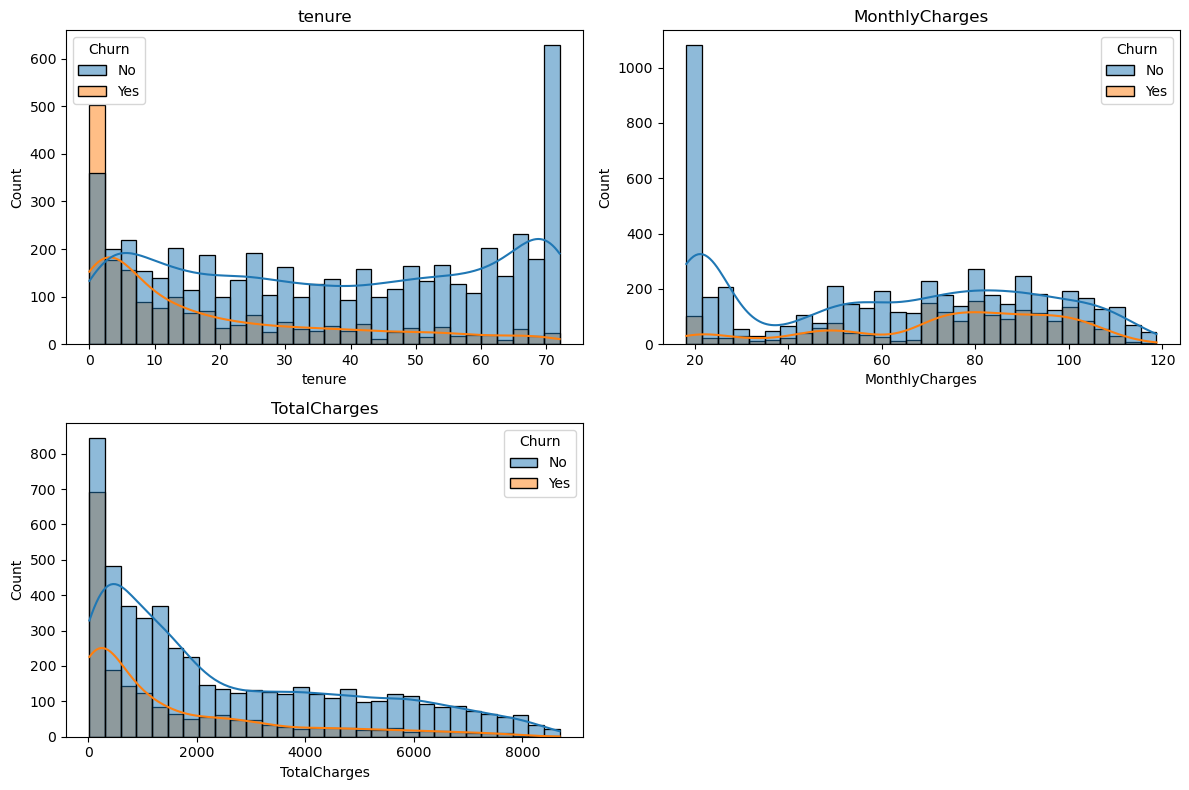

In [92]:
numeric_cols = df.select_dtypes(include="number").columns
n = len(numeric_cols)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))

for i, col in enumerate(numeric_cols):
    ax = axes.flatten()[i]

    sns.histplot(
        data=df,
        x=col,
        hue="Churn",
        bins=30,
        kde=True,
        common_norm=False,
        ax=ax
    )

    ax.set_title(col)

for j in range(i + 1, rows * cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

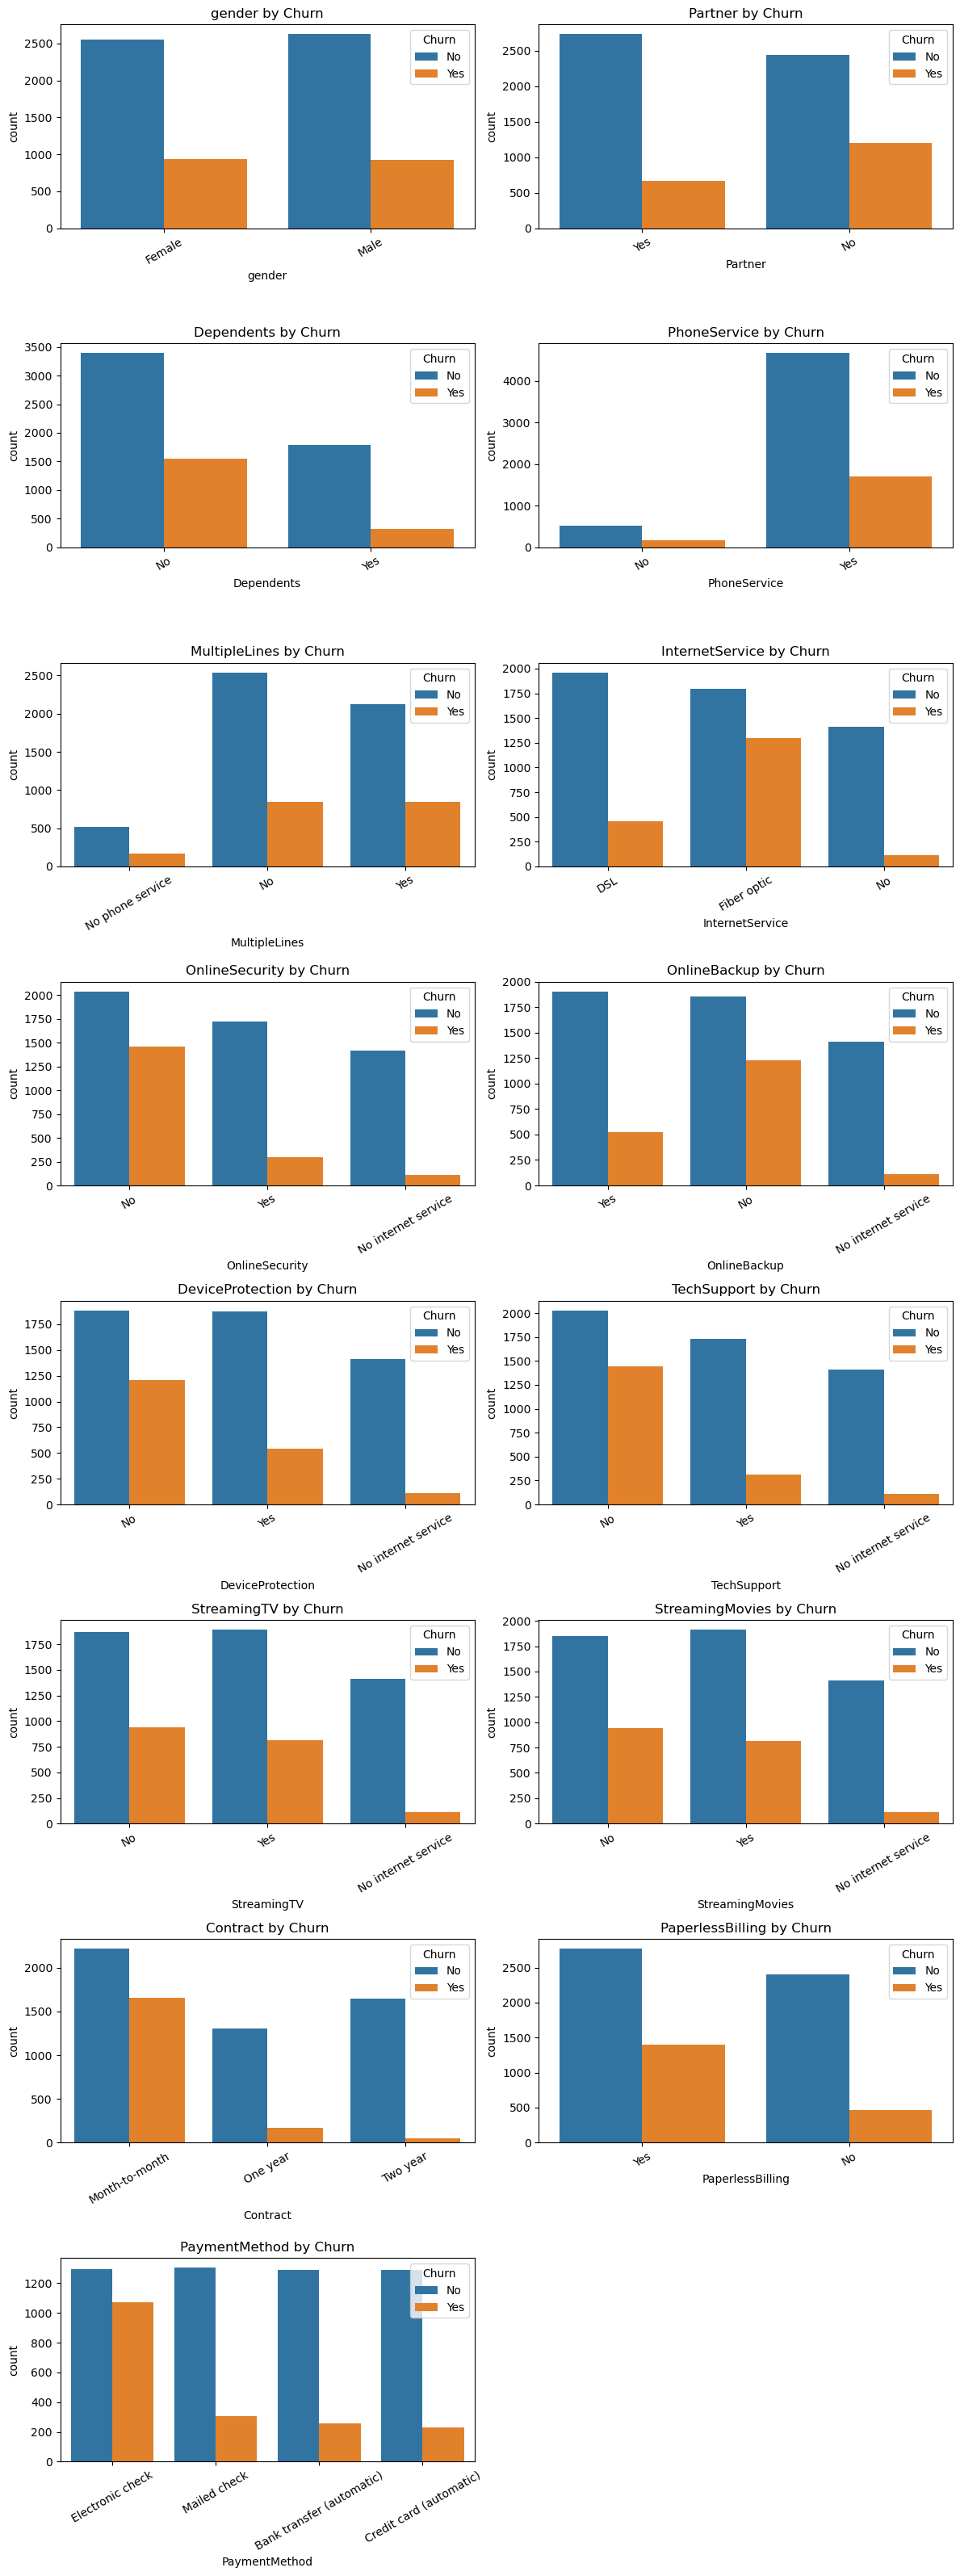

In [94]:
categorical_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col not in ["customerID", "Churn"]
]

n = len(categorical_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} by Churn")
    axes[i].tick_params(axis="x", rotation=30)

# remove unused panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

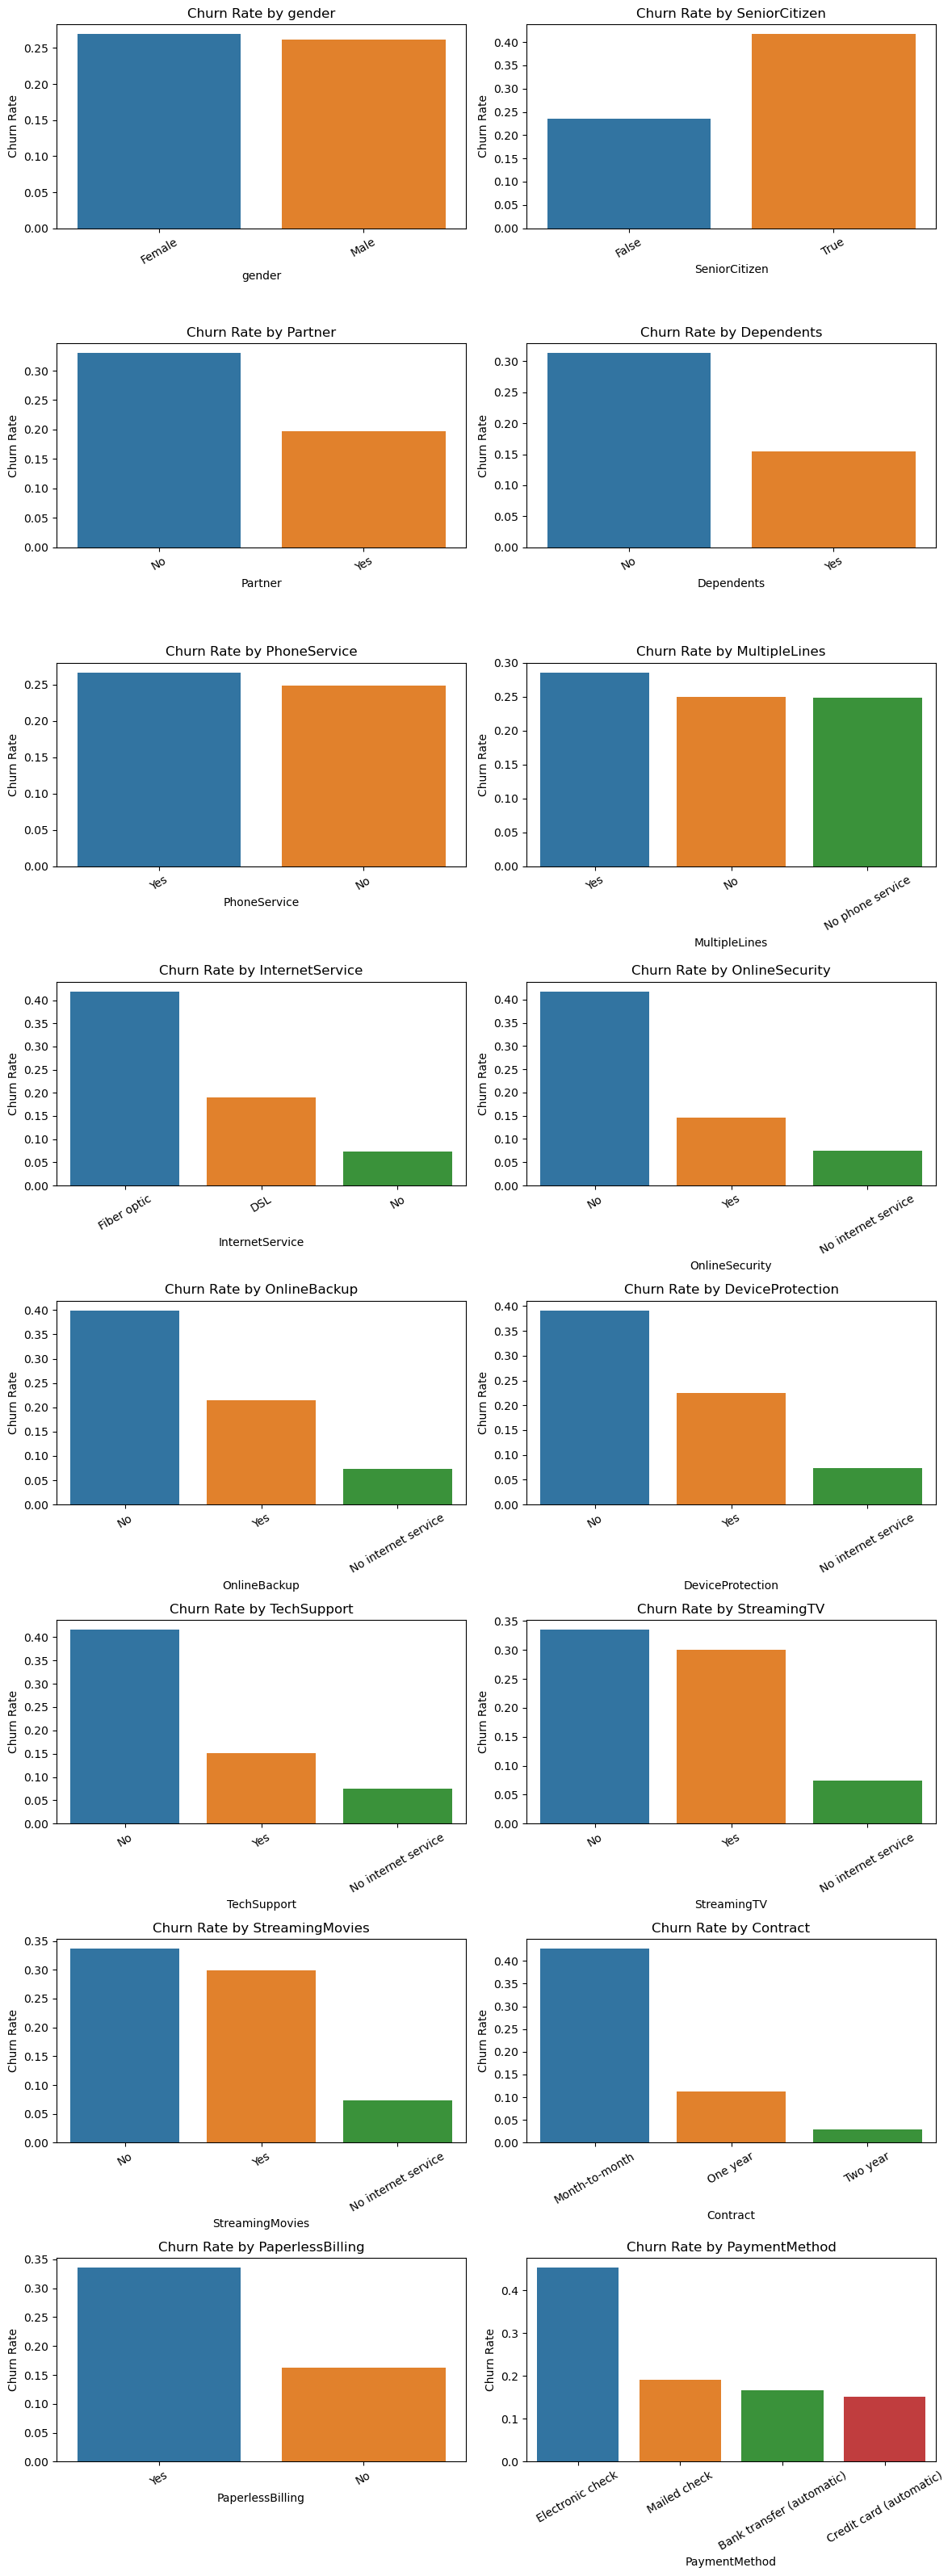

In [93]:
categorical_cols = [
    col for col in df.select_dtypes(include=["object", "boolean"]).columns
    if col not in ["customerID", "Churn"] and df[col].nunique() <= 10
]

tmp = df.copy()
tmp["ChurnFlag"] = (tmp["Churn"] == "Yes").astype(int)

n = len(categorical_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    plot_df = (
        tmp.groupby(col, dropna=False)["ChurnFlag"]
        .mean()
        .reset_index()
        .sort_values("ChurnFlag", ascending=False)
    )

    sns.barplot(
        data=plot_df,
        x=col,
        y="ChurnFlag",
        ax=axes[i]
    )

    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis="x", rotation=30)

# remove unused panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Clean Data

In [79]:
# Fix Total Charges from dtype object to float

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

In [85]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool) # convert explicitly to boolean

In [86]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Feature Engineering

In [102]:
import numpy as np

# --- clean base columns ---
df = df.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

# target flag
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

# --- lifetime / pricing features ---
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

df["price_ratio"] = np.where(
    df["avg_monthly_spend"] > 0,
    df["MonthlyCharges"] / df["avg_monthly_spend"],
    1.0
)

# --- tenure / lifecycle buckets ---
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 0, 12, 24, 48, 72],
    labels=["new", "0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)

df["customer_stage"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 24, 60, np.inf],
    labels=["new", "established", "loyal", "long_term"]
)

# --- contract / billing indicators ---
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
df["auto_pay"] = df["PaymentMethod"].str.contains("automatic", case=False, na=False).astype(int)
df["paperless"] = (df["PaperlessBilling"] == "Yes").astype(int)

# --- service indicators ---
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# count only explicit Yes values
df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)
df["service_adoption_rate"] = df["num_services"] / len(service_cols)

df["has_support"] = (
    ((df["OnlineSecurity"] == "Yes") | (df["TechSupport"] == "Yes"))
).astype(int)

df["has_streaming"] = (
    ((df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes"))
).astype(int)

df["multi_service_customer"] = (df["num_services"] >= 4).astype(int)

# --- product / risk indicators ---
df["fiber_customer"] = (df["InternetService"] == "Fiber optic").astype(int)
df["electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)
df["senior_citizen"] = df["SeniorCitizen"].astype(int)

# --- pricing / value flags ---
df["high_bill"] = (df["MonthlyCharges"] > df["MonthlyCharges"].quantile(0.75)).astype(int)
df["low_tenure_high_bill"] = (
    (df["tenure"] <= 12) & (df["MonthlyCharges"] > df["MonthlyCharges"].median())
).astype(int)

df["revenue_risk_proxy"] = df["MonthlyCharges"] * np.maximum(df["tenure"], 1)

# --- interaction features ---
df["fiber_monthly"] = (
    (df["InternetService"] == "Fiber optic") &
    (df["Contract"] == "Month-to-month")
).astype(int)

df["month_to_month_no_support"] = (
    (df["Contract"] == "Month-to-month") &
    (df["has_support"] == 0)
).astype(int)

df["high_value_long_tenure"] = (
    (df["MonthlyCharges"] > df["MonthlyCharges"].quantile(0.75)) &
    (df["tenure"] > 24)
).astype(int)

# optional quick check
print(df.shape)
df.head()

(7043, 43)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,multi_service_customer,fiber_customer,electronic_check,senior_citizen,high_bill,low_tenure_high_bill,revenue_risk_proxy,fiber_monthly,month_to_month_no_support,high_value_long_tenure
0,7590-VHVEG,Female,False,Yes,No,1,No,No phone service,DSL,No,...,0,0,1,0,0,0,29.85,0,1,0
1,5575-GNVDE,Male,False,No,No,34,Yes,No,DSL,Yes,...,0,0,0,0,0,0,1936.30,0,0,0
2,3668-QPYBK,Male,False,No,No,2,Yes,No,DSL,Yes,...,0,0,0,0,0,0,107.70,0,0,0
3,7795-CFOCW,Male,False,No,No,45,No,No phone service,DSL,Yes,...,0,0,0,0,0,0,1903.50,0,0,0
4,9237-HQITU,Female,False,No,No,2,Yes,No,Fiber optic,No,...,0,1,1,0,0,1,141.40,1,1,0


In [105]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# -----------------------------
# Target and features
# -----------------------------
y = df["ChurnFlag"].copy()

X = df.drop(columns=[
    "Churn",
    "ChurnFlag",
    "customerID"
]).copy()

# -----------------------------
# Robust column typing
# -----------------------------
numeric_cols = []
categorical_cols = []

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]) and not pd.api.types.is_bool_dtype(X[col]):
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

# force categoricals to string and fill missing BEFORE pipeline
for col in categorical_cols:
    X[col] = X[col].astype("string").fillna("__missing__")

# -----------------------------
# Train / dev / test split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# -----------------------------
# Pipelines
# -----------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# -----------------------------
# Fit + transform
# -----------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_dev_processed = preprocessor.transform(X_dev)
X_test_processed = preprocessor.transform(X_test)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Train:", X_train_processed.shape)
print("Dev:", X_dev_processed.shape)
print("Test:", X_test_processed.shape)

Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'price_ratio', 'is_month_to_month', 'auto_pay', 'paperless', 'num_services', 'service_adoption_rate', 'has_support', 'has_streaming', 'multi_service_customer', 'fiber_customer', 'electronic_check', 'senior_citizen', 'high_bill', 'low_tenure_high_bill', 'revenue_risk_proxy', 'fiber_monthly', 'month_to_month_no_support', 'high_value_long_tenure']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'customer_stage']
Train: (4930, 74)
Dev: (1056, 74)
Test: (1057, 74)


# Model Training

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb

# Logistic regression baseline
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_processed, y_train)

log_preds = log_model.predict_proba(X_dev_processed)[:,1]

print("Logistic ROC-AUC:", roc_auc_score(y_dev, log_preds))


# XGBoost baseline
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

xgb_preds = xgb_model.predict_proba(X_dev_processed)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_dev, xgb_preds))

Logistic ROC-AUC: 0.8501449742268041
XGBoost ROC-AUC: 0.8176109167893961


In [109]:
import optuna
from sklearn.metrics import roc_auc_score
import xgboost as xgb

def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10)
    }

    model = xgb.XGBClassifier(**params)

    model.fit(X_train_processed, y_train)

    preds = model.predict_proba(X_dev_processed)[:,1]

    score = roc_auc_score(y_dev, preds)

    return score


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=40)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-12 11:59:49,335] A new study created in memory with name: no-name-4b87b4c5-f5ea-4f41-8871-0167839e4624
[I 2026-03-12 11:59:50,840] Trial 0 finished with value: 0.8442401509572901 and parameters: {'n_estimators': 259, 'max_depth': 8, 'learning_rate': 0.013698173852389178, 'subsample': 0.8844433034757488, 'colsample_bytree': 0.8638142642427551, 'gamma': 0.08295079506814684, 'min_child_weight': 7}. Best is trial 0 with value: 0.8442401509572901.
[I 2026-03-12 11:59:53,846] Trial 1 finished with value: 0.8358109351988218 and parameters: {'n_estimators': 474, 'max_depth': 10, 'learning_rate': 0.15185416220718712, 'subsample': 0.9790480473882752, 'colsample_bytree': 0.8890062890223089, 'gamma': 3.8003814715577615, 'min_child_weight': 7}. Best is trial 0 with value: 0.8442401509572901.
[I 2026-03-12 11:59:58,214] Trial 2 finished with value: 0.8363448085419735 and parameters: {'n_estimators': 573, 'max_depth': 8, 'learning_rate': 0.0757328920863188, 'subsample': 0.9849275784613224,

[I 2026-03-12 12:00:23,414] Trial 23 finished with value: 0.849654823269514 and parameters: {'n_estimators': 175, 'max_depth': 4, 'learning_rate': 0.0714522984555471, 'subsample': 0.8242712091124971, 'colsample_bytree': 0.7761604433765465, 'gamma': 2.6027982846742654, 'min_child_weight': 10}. Best is trial 14 with value: 0.8508744477172312.
[I 2026-03-12 12:00:24,523] Trial 24 finished with value: 0.8436096281296024 and parameters: {'n_estimators': 286, 'max_depth': 5, 'learning_rate': 0.041960695801108866, 'subsample': 0.7699665037878802, 'colsample_bytree': 0.6975026209445873, 'gamma': 2.4759096369033, 'min_child_weight': 8}. Best is trial 14 with value: 0.8508744477172312.
[I 2026-03-12 12:00:25,233] Trial 25 finished with value: 0.8365450110456555 and parameters: {'n_estimators': 165, 'max_depth': 6, 'learning_rate': 0.0786432932594545, 'subsample': 0.7152535001144592, 'colsample_bytree': 0.8627086581444796, 'gamma': 1.434247054841864, 'min_child_weight': 9}. Best is trial 14 with 

Best score: 0.8508744477172312
Best params: {'n_estimators': 105, 'max_depth': 5, 'learning_rate': 0.035685353329589234, 'subsample': 0.7768022471255511, 'colsample_bytree': 0.8148057152416553, 'gamma': 2.00313964445024, 'min_child_weight': 10}


In [110]:
best_params = study.best_params

final_model = xgb.XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

final_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8148057152416553, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=2.00313964445024, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.035685353329589234, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              n_estimators=105, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [111]:
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

dev_preds = final_model.predict_proba(X_dev_processed)[:,1]

auc = roc_auc_score(y_dev, dev_preds)

print("Final Test ROC-AUC:", auc)

# threshold classification
pred_labels = (dev_preds > 0.5).astype(int)

print(classification_report(y_dev, pred_labels))
print(confusion_matrix(y_dev, pred_labels))

Final Test ROC-AUC: 0.8508744477172312
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       776
           1       0.66      0.53      0.58       280

    accuracy                           0.80      1056
   macro avg       0.75      0.71      0.73      1056
weighted avg       0.79      0.80      0.79      1056

[[700  76]
 [133 147]]


Recall is unacceptably low for a churn model, typically we prioritize recall with an acceptable precision lower threshold. Further improvements to the featureset and model are needed here.

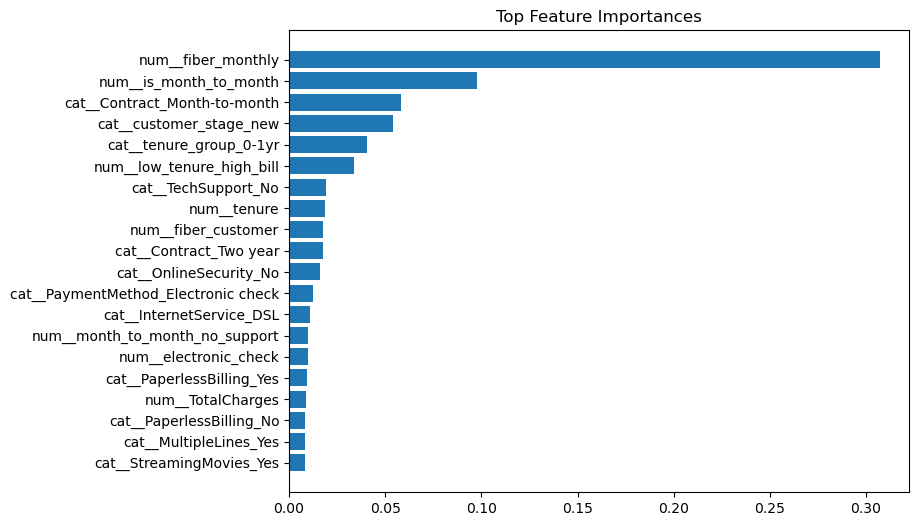

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

importances = final_model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8,6))
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

In [114]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    final_model,
    method="isotonic",
    cv=3
)

calibrated_model.fit(X_train_processed, y_train)

calibrated_preds = calibrated_model.predict_proba(X_dev_processed)[:,1]

print("Calibrated AUC:", roc_auc_score(y_dev, calibrated_preds))

Calibrated AUC: 0.8496525220913108


In [116]:
revenue_at_risk = (
    calibrated_preds *
    df.loc[y_dev.index, "MonthlyCharges"]
)

print("Estimated revenue at risk:", revenue_at_risk.sum())

Estimated revenue at risk: 21831.182756394137


# Next Steps

Start to productionalize this code logic as well as add some additional feature engineering.